In [1]:
print("\n" + "="*60)
print("题目2.1 卷积层理论计算")
print("="*60)

# 输入参数
input_channels = 3
input_height = 32
input_width = 32
num_kernels = 16
kernel_size = 5  # 5x5
padding = 2
stride = 2
# 1. 计算输出特征图尺寸
output_height = (input_height - kernel_size + 2 * padding) // stride + 1
output_width = (input_width - kernel_size + 2 * padding) // stride + 1
output_channels = num_kernels

print(f"1. 输出特征图尺寸: {output_channels} × {output_height} × {output_width}")
# 验证: (32-5+4)/2+1 = (31)/2+1 = 15.5+1? 实际上是整数除法
# (32-5+4)=31, 31//2=15, 15+1=16
print(f"   (计算过程: ({input_height}-{kernel_size}+2×{padding})/{stride}+1 = {output_height})")

# 2. 计算单个输出通道的一个像素值的乘法操作次数
# 每个输出像素需要: 输入通道数 × 卷积核高 × 卷积核宽 次乘法
mult_ops_per_pixel = input_channels * kernel_size * kernel_size
print(f"\n2. 单个输出通道的一个像素值需要的乘法次数: {mult_ops_per_pixel}")
print(f"   (输入通道数 {input_channels} × 卷积核尺寸 {kernel_size}×{kernel_size})")
print(f"   即: {input_channels} × {kernel_size} × {kernel_size} = {mult_ops_per_pixel}")


题目2.1 卷积层理论计算
1. 输出特征图尺寸: 16 × 16 × 16
   (计算过程: (32-5+2×2)/2+1 = 16)

2. 单个输出通道的一个像素值需要的乘法次数: 75
   (输入通道数 3 × 卷积核尺寸 5×5)
   即: 3 × 5 × 5 = 75


最大池化测试结果
输入形状: (2, 3, 8, 8)
输出形状: (2, 3, 4, 4)
手动实现输出形状: (2, 3, 4, 4)
PyTorch输出形状: (2, 3, 4, 4)

最大差异: 0.000000
平均差异: 0.000000

✓ 手动实现与PyTorch官方实现结果一致！


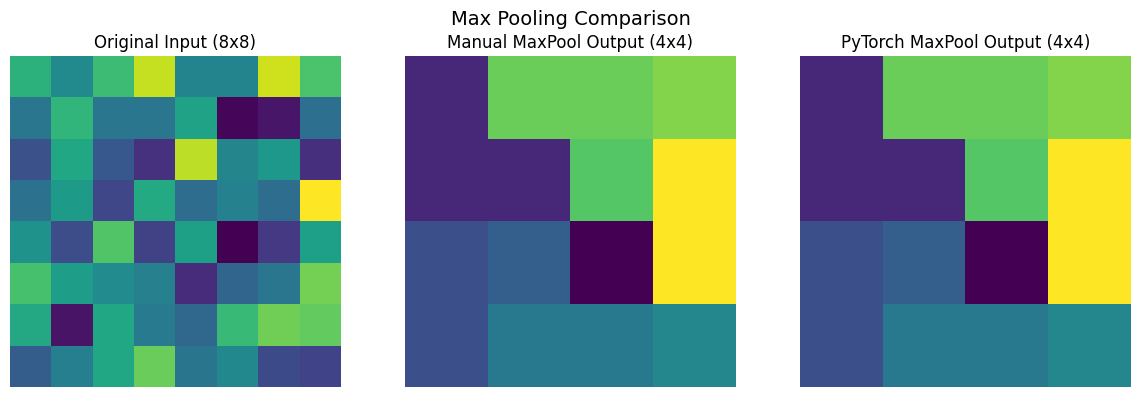

In [3]:
# ## 2.2 编程题：手动实现最大池化

# %%
import numpy as np
import torch
import matplotlib.pyplot as plt

def max_pool2d_manual(input_tensor, kernel_size, stride=1, padding=0):
    """
    手动实现二维最大池化
    
    Args:
        input_tensor: 输入张量，形状 (batch_size, channels, height, width)
        kernel_size: 池化核大小，整数或元组
        stride: 步幅，整数或元组
        padding: 填充，整数或元组
    
    Returns:
        池化后的输出张量
    """
    # 处理参数
    if isinstance(kernel_size, int):
        k_h = k_w = kernel_size
    else:
        k_h, k_w = kernel_size
    
    if isinstance(stride, int):
        s_h = s_w = stride
    else:
        s_h, s_w = stride
    
    if isinstance(padding, int):
        p_h = p_w = padding
    else:
        p_h, p_w = padding
    
    # 获取输入形状
    batch_size, channels, h_in, w_in = input_tensor.shape
    
    # 添加填充
    if padding > 0:
        padded_tensor = np.pad(
            input_tensor,
            pad_width=((0, 0), (0, 0), (p_h, p_h), (p_w, p_w)),
            mode='constant',
            constant_values=float('-inf')
        )
    else:
        padded_tensor = input_tensor
    
    # 计算输出尺寸
    h_out = (h_in + 2 * p_h - k_h) // s_h + 1
    w_out = (w_in + 2 * p_w - k_w) // s_w + 1
    
    # 初始化输出
    output = np.zeros((batch_size, channels, h_out, w_out))
    
    # 执行池化操作
    for b in range(batch_size):
        for c in range(channels):
            for i in range(h_out):
                for j in range(w_out):
                    # 计算池化窗口位置
                    h_start = i * s_h
                    h_end = h_start + k_h
                    w_start = j * s_w
                    w_end = w_start + k_w
                    
                    # 提取窗口并取最大值
                    window = padded_tensor[b, c, h_start:h_end, w_start:w_end]
                    output[b, c, i, j] = np.max(window)
    
    return output


def test_max_pool():
    # 创建测试数据
    np.random.seed(42)
    test_input = np.random.randn(2, 3, 8, 8).astype(np.float32)
    
    # 手动实现
    manual_output = max_pool2d_manual(test_input, kernel_size=3, stride=2, padding=1)
    
    # PyTorch官方实现（用于对比）
    test_tensor = torch.tensor(test_input)
    pytorch_pool = torch.nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
    pytorch_output = pytorch_pool(test_tensor).numpy()
    
    print("=" * 50)
    print("最大池化测试结果")
    print("=" * 50)
    print(f"输入形状: {test_input.shape}")
    print(f"输出形状: {manual_output.shape}")
    print(f"手动实现输出形状: {manual_output.shape}")
    print(f"PyTorch输出形状: {pytorch_output.shape}")
    
    # 比较结果
    diff = np.abs(manual_output - pytorch_output)
    print(f"\n最大差异: {diff.max():.6f}")
    print(f"平均差异: {diff.mean():.6f}")
    
    if np.allclose(manual_output, pytorch_output, atol=1e-6):
        print("\n✓ 手动实现与PyTorch官方实现结果一致！")
    else:
        print("\n✗ 结果存在差异")
    
    return manual_output, pytorch_output, test_input  # 返回 test_input


manual_out, pytorch_out, test_input = test_max_pool()  # 接收三个返回值

# 可视化池化效果
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 原始输入（第一个batch，第一个通道）
axes[0].imshow(test_input[0, 0], cmap='viridis')
axes[0].set_title('Original Input (8x8)')
axes[0].axis('off')

# 手动池化结果
axes[1].imshow(manual_out[0, 0], cmap='viridis')
axes[1].set_title('Manual MaxPool Output (4x4)')
axes[1].axis('off')

# PyTorch池化结果
axes[2].imshow(pytorch_out[0, 0], cmap='viridis')
axes[2].set_title('PyTorch MaxPool Output (4x4)')
axes[2].axis('off')

plt.suptitle('Max Pooling Comparison', fontsize=14)
plt.tight_layout()
plt.show()



In [5]:
# ============================================
# 题目3.1 VGG参数量计算
# ============================================
print("\n" + "="*60)
print("题目3.1 VGG参数量计算")
print("="*60)

# 假设输入和输出通道数均为 C
C = 1  # 用符号表示，实际计算时用变量

print("设输入和输出特征图的通道数均为 C")
print()

# 1. 单个 5x5 卷积层的参数量
# 参数量 = 输入通道数 × 卷积核高 × 卷积核宽 × 输出通道数
params_5x5 = C * 5 * 5 * C
print(f"1. 一个 5×5 卷积层（不带偏置）的参数量: {C} × 5 × 5 × {C} = 25C²")
print(f"   即: 25 × C²")

# 2. 两个串联的 3x3 卷积层的总参数量
# 第一层: C × 3 × 3 × C = 9C²
# 第二层: C × 3 × 3 × C = 9C²
# 总计: 18C²
params_two_3x3 = 2 * (C * 3 * 3 * C)
print(f"\n2. 两个串联的 3×3 卷积层（不带偏置）的总参数量:")
print(f"   第一层: {C} × 3 × 3 × {C} = 9C²")
print(f"   第二层: {C} × 3 × 3 × {C} = 9C²")
print(f"   总计: 9C² + 9C² = 18C²")

# 修正：将平方符号移到引号外面或者使用其他表示方式
print(f"\n结论: 两个 3×3 卷积层 (18C²) 比单个 5×5 卷积层 (25C²) 参数量更少")
print(f"       节省了 {(25-18)/25*100:.0f}% 的参数")


题目3.1 VGG参数量计算
设输入和输出特征图的通道数均为 C

1. 一个 5×5 卷积层（不带偏置）的参数量: 1 × 5 × 5 × 1 = 25C²
   即: 25 × C²

2. 两个串联的 3×3 卷积层（不带偏置）的总参数量:
   第一层: 1 × 3 × 3 × 1 = 9C²
   第二层: 1 × 3 × 3 × 1 = 9C²
   总计: 9C² + 9C² = 18C²

结论: 两个 3×3 卷积层 (18C²) 比单个 5×5 卷积层 (25C²) 参数量更少
       节省了 28% 的参数


In [6]:
# ## 3.2 编程题：NiN块实现

# %%
import torch
import torch.nn as nn

class NiNBlock(nn.Module):
    """
    NiN块：普通卷积层 + 两个1×1卷积层
    每个卷积层后都紧跟ReLU激活函数
    """
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super(NiNBlock, self).__init__()
        
        # 第一个卷积层：普通卷积
        self.conv1 = nn.Conv2d(in_channels, out_channels, 
                                kernel_size=kernel_size, 
                                stride=stride, 
                                padding=padding)
        self.relu1 = nn.ReLU()
        
        # 第二个卷积层：1×1卷积
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=1)
        self.relu2 = nn.ReLU()
        
        # 第三个卷积层：1×1卷积
        self.conv3 = nn.Conv2d(out_channels, out_channels, kernel_size=1)
        self.relu3 = nn.ReLU()
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.conv3(x)
        x = self.relu3(x)
        return x


# 测试NiN块
def test_nin_block():
    print("=" * 50)
    print("NiN块测试")
    print("=" * 50)
    
    # 创建NiN块
    nin_block = NiNBlock(in_channels=3, out_channels=96, 
                          kernel_size=3, stride=1, padding=1)
    
    # 创建测试输入
    test_input = torch.randn(1, 3, 32, 32)
    
    # 前向传播
    output = nin_block(test_input)
    
    print(f"输入形状: {test_input.shape}")
    print(f"输出形状: {output.shape}")
    print(f"\nNiN块结构:")
    print(nin_block)
    
    # 统计参数量
    total_params = sum(p.numel() for p in nin_block.parameters())
    print(f"\n总参数量: {total_params:,}")
    
    return nin_block


nin_block = test_nin_block()

NiN块测试
输入形状: torch.Size([1, 3, 32, 32])
输出形状: torch.Size([1, 96, 32, 32])

NiN块结构:
NiNBlock(
  (conv1): Conv2d(3, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (conv2): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1))
  (relu2): ReLU()
  (conv3): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1))
  (relu3): ReLU()
)

总参数量: 21,312


In [7]:
# ============================================
# 题目4.1 批量归一化计算
# ============================================
print("\n" + "="*60)
print("题目4.1 批量归一化计算")
print("="*60)

import numpy as np

# 输入数据
x = np.array([2, 4, 6, 8])
gamma = 2  # 缩放参数
beta = 1   # 平移参数
epsilon = 0

# 计算均值和方差
mu = np.mean(x)
var = np.var(x)  # 总体方差

print(f"输入数据: x = {x}")
print(f"均值 μ = {mu}")
print(f"方差 σ² = {var}")

# Batch Normalization 公式:
# y = γ * (x - μ) / sqrt(σ² + ε) + β

# 计算输出
y = gamma * (x - mu) / np.sqrt(var + epsilon) + beta

print(f"\n计算过程:")
print(f"y = γ × (x - μ) / √(σ² + ε) + β")
print(f"  = {gamma} × (x - {mu}) / √({var} + {epsilon}) + {beta}")

print(f"\n最终输出:")
for i, val in enumerate(y):
    print(f"  y_{i+1} = {val:.4f}")

# 验证计算
print(f"\n验证:")
print(f"标准化后: {(x - mu)/np.sqrt(var)}")
print(f"缩放平移后: {gamma * (x - mu)/np.sqrt(var) + beta}")


题目4.1 批量归一化计算
输入数据: x = [2 4 6 8]
均值 μ = 5.0
方差 σ² = 5.0

计算过程:
y = γ × (x - μ) / √(σ² + ε) + β
  = 2 × (x - 5.0) / √(5.0 + 0) + 1

最终输出:
  y_1 = -1.6833
  y_2 = 0.1056
  y_3 = 1.8944
  y_4 = 3.6833

验证:
标准化后: [-1.34164079 -0.4472136   0.4472136   1.34164079]
缩放平移后: [-1.68328157  0.10557281  1.89442719  3.68328157]


In [8]:
# ## 4.2 编程题：残差块实现

# %%
class ResidualBlock(nn.Module):
    """
    残差块实现
    
    包含两个3×3卷积层，每个卷积层后跟批量归一化层
    支持使用1×1卷积调整输入形状以实现残差连接
    """
    def __init__(self, in_channels, out_channels, use_1x1conv=False, stride=1):
        super(ResidualBlock, self).__init__()
        
        # 第一个卷积层
        self.conv1 = nn.Conv2d(in_channels, out_channels, 
                                kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        # 第二个卷积层
        self.conv2 = nn.Conv2d(out_channels, out_channels, 
                                kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # 1×1卷积层（用于调整输入形状）
        self.use_1x1conv = use_1x1conv
        if use_1x1conv or stride != 1 or in_channels != out_channels:
            self.conv_shortcut = nn.Conv2d(in_channels, out_channels, 
                                            kernel_size=1, stride=stride)
            self.bn_shortcut = nn.BatchNorm2d(out_channels)
        else:
            self.conv_shortcut = None
        
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        identity = x
        
        # 主路径
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        # 残差连接
        if self.conv_shortcut is not None:
            identity = self.conv_shortcut(x)
            identity = self.bn_shortcut(identity)
        
        out += identity
        out = self.relu(out)
        
        return out


# 测试残差块
def test_residual_block():
    print("=" * 50)
    print("残差块测试")
    print("=" * 50)
    
    # 测试相同输入输出通道
    block1 = ResidualBlock(64, 64, use_1x1conv=False)
    test_input1 = torch.randn(1, 64, 32, 32)
    output1 = block1(test_input1)
    print(f"相同通道数 (64->64):")
    print(f"  输入形状: {test_input1.shape}")
    print(f"  输出形状: {output1.shape}")
    
    # 测试不同输入输出通道
    block2 = ResidualBlock(64, 128, use_1x1conv=True, stride=2)
    test_input2 = torch.randn(1, 64, 32, 32)
    output2 = block2(test_input2)
    print(f"\n不同通道数 (64->128, stride=2):")
    print(f"  输入形状: {test_input2.shape}")
    print(f"  输出形状: {output2.shape}")
    
    # 打印网络结构
    print(f"\n残差块结构:")
    print(block1)
    
    # 统计参数量
    params = sum(p.numel() for p in block1.parameters())
    print(f"\n总参数量: {params:,}")
    
    return block1, block2


res_block1, res_block2 = test_residual_block()

残差块测试
相同通道数 (64->64):
  输入形状: torch.Size([1, 64, 32, 32])
  输出形状: torch.Size([1, 64, 32, 32])

不同通道数 (64->128, stride=2):
  输入形状: torch.Size([1, 64, 32, 32])
  输出形状: torch.Size([1, 128, 16, 16])

残差块结构:
ResidualBlock(
  (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
)

总参数量: 74,112


图像增广管道
增广管道组成:
  1. RandomResizedCrop
  2. RandomHorizontalFlip
  3. ColorJitter
  4. ToTensor
  5. Normalize


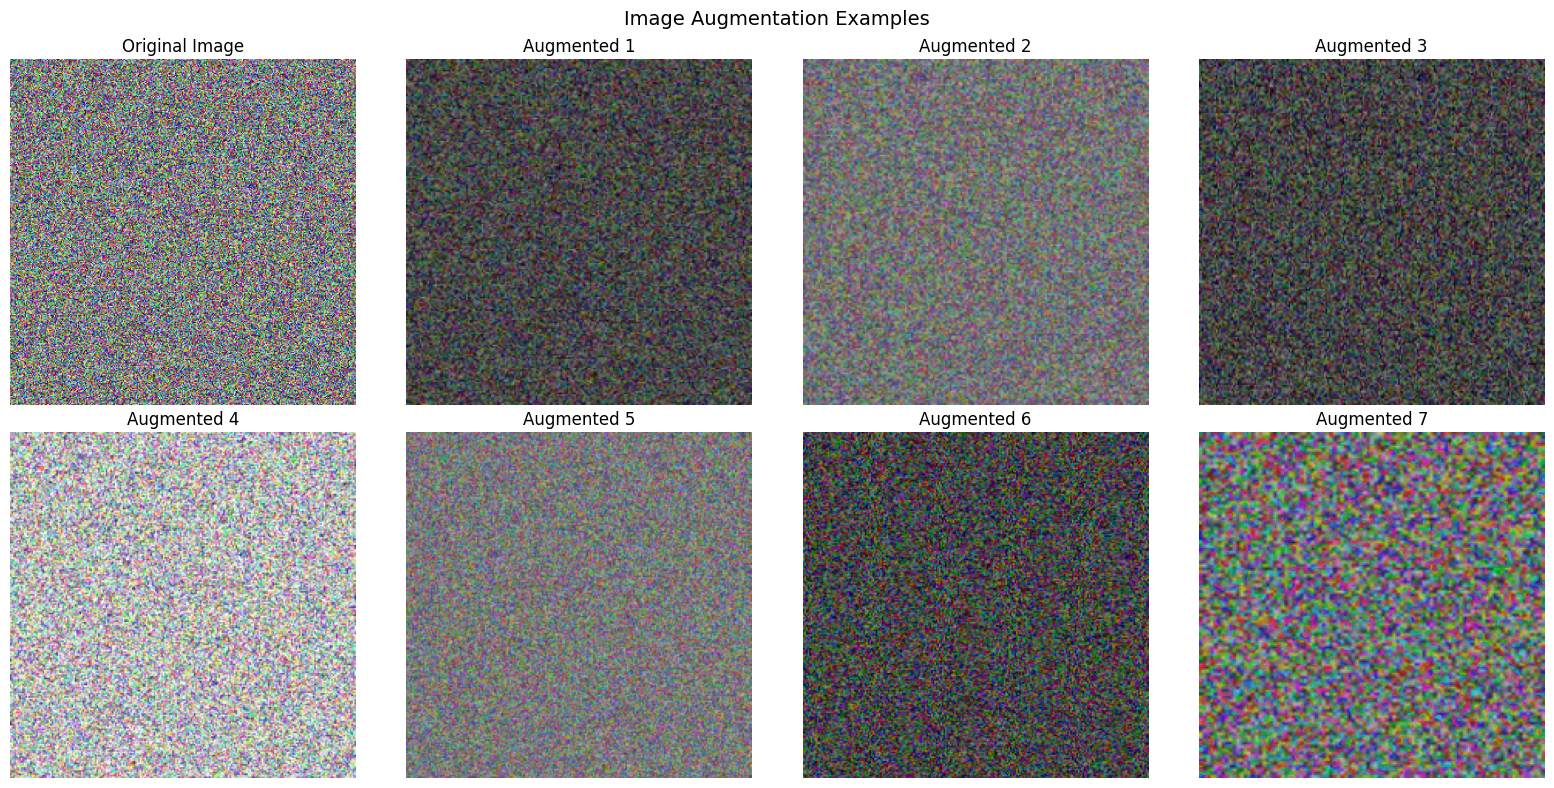

In [9]:
# ## 5.2 编程题：图像增广管道

# %%
from torchvision import transforms
from PIL import Image
import numpy as np

def create_augmentation_pipeline():
    """
    创建图像增广管道
    
    包括：
    1. 随机裁剪并缩放到224×224
    2. 50%概率水平翻转
    3. 随机改变亮度、对比度、饱和度
    4. 转换为张量
    """
    pipeline = transforms.Compose([
        # 1. 随机裁剪并缩放
        transforms.RandomResizedCrop(
            size=224,
            scale=(0.08, 1.0),  # 面积比例范围
            ratio=(3/4, 4/3)     # 宽高比范围
        ),
        
        # 2. 随机水平翻转（50%概率）
        transforms.RandomHorizontalFlip(p=0.5),
        
        # 3. 随机颜色扰动
        transforms.ColorJitter(
            brightness=0.5,   # 亮度变化范围
            contrast=0.5,     # 对比度变化范围
            saturation=0.5,   # 饱和度变化范围
            hue=0.1           # 色调变化范围
        ),
        
        # 4. 转换为张量
        transforms.ToTensor(),
        
        # 可选：标准化（通常ImageNet预训练模型需要）
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                           std=[0.229, 0.224, 0.225])
    ])
    
    return pipeline


def visualize_augmentations(pipeline, image_path=None, num_samples=8):
    """
    可视化图像增广效果
    """
    # 创建示例图像
    if image_path is None:
        # 创建一个示例图像
        img_array = np.random.randint(0, 255, (300, 300, 3), dtype=np.uint8)
        image = Image.fromarray(img_array)
    else:
        image = Image.open(image_path).convert('RGB')
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()
    
    # 显示原图
    axes[0].imshow(image)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    # 显示增广后的图像
    for i in range(1, min(num_samples, 8)):
        augmented = pipeline(image)
        # 反标准化用于显示
        augmented_display = augmented.numpy().transpose(1, 2, 0)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        augmented_display = std * augmented_display + mean
        augmented_display = np.clip(augmented_display, 0, 1)
        
        axes[i].imshow(augmented_display)
        axes[i].set_title(f'Augmented {i}')
        axes[i].axis('off')
    
    plt.suptitle('Image Augmentation Examples', fontsize=14)
    plt.tight_layout()
    plt.show()


# 测试图像增广管道
print("=" * 50)
print("图像增广管道")
print("=" * 50)

pipeline = create_augmentation_pipeline()
print("增广管道组成:")
for i, transform in enumerate(pipeline.transforms):
    print(f"  {i+1}. {transform.__class__.__name__}")

# 可视化增广效果
visualize_augmentations(pipeline)

IoU计算
真实框 A: [10, 10, 50, 50]
预测框 B: [30, 30, 70, 70]

框A面积: 1600
框B面积: 1600
交集面积: 400
并集面积: 2800

IoU = 400 / 2800 = 0.142857
IoU分数: 0.142857 ≈ 0.1429


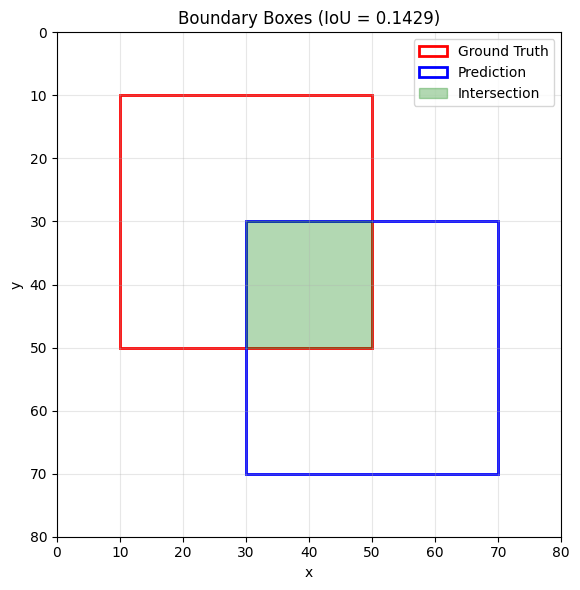

In [10]:
# ## 6.1 理论计算题
# %%
def calculate_iou(box1, box2):
    """
    计算两个边界框的IoU
    
    Args:
        box1, box2: [x1, y1, x2, y2] 格式的边界框
    """
    x1_min, y1_min, x1_max, y1_max = box1
    x2_min, y2_min, x2_max, y2_max = box2
    
    # 计算交区域
    inter_x_min = max(x1_min, x2_min)
    inter_y_min = max(y1_min, y2_min)
    inter_x_max = min(x1_max, x2_max)
    inter_y_max = min(y1_max, y2_max)
    
    # 计算交区域面积
    inter_width = max(0, inter_x_max - inter_x_min)
    inter_height = max(0, inter_y_max - inter_y_min)
    inter_area = inter_width * inter_height
    
    # 计算各自面积
    area1 = (x1_max - x1_min) * (y1_max - y1_min)
    area2 = (x2_max - x2_min) * (y2_max - y2_min)
    
    # 计算并集面积
    union_area = area1 + area2 - inter_area
    
    # 计算IoU
    iou = inter_area / union_area if union_area > 0 else 0
    
    return iou, inter_area, union_area, area1, area2


# 计算IoU
box_A = [10, 10, 50, 50]
box_B = [30, 30, 70, 70]

iou, inter_area, union_area, area_A, area_B = calculate_iou(box_A, box_B)

print("=" * 50)
print("IoU计算")
print("=" * 50)
print(f"真实框 A: {box_A}")
print(f"预测框 B: {box_B}")
print(f"\n框A面积: {area_A}")
print(f"框B面积: {area_B}")
print(f"交集面积: {inter_area}")
print(f"并集面积: {union_area}")
print(f"\nIoU = {inter_area} / {union_area} = {iou:.6f}")
print(f"IoU分数: {iou:.6f} ≈ {iou:.4f}")

# 可视化两个框
def visualize_boxes(box1, box2):
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    
    # 绘制框A
    rect1 = plt.Rectangle((box1[0], box1[1]), box1[2]-box1[0], box1[3]-box1[1],
                           fill=False, edgecolor='red', linewidth=2, label='Ground Truth')
    ax.add_patch(rect1)
    
    # 绘制框B
    rect2 = plt.Rectangle((box2[0], box2[1]), box2[2]-box2[0], box2[3]-box2[1],
                           fill=False, edgecolor='blue', linewidth=2, label='Prediction')
    ax.add_patch(rect2)
    
    # 绘制交集区域
    inter_x_min = max(box1[0], box2[0])
    inter_y_min = max(box1[1], box2[1])
    inter_width = min(box1[2], box2[2]) - inter_x_min
    inter_height = min(box1[3], box2[3]) - inter_y_min
    if inter_width > 0 and inter_height > 0:
        inter_rect = plt.Rectangle((inter_x_min, inter_y_min), inter_width, inter_height,
                                     fill=True, alpha=0.3, color='green', label='Intersection')
        ax.add_patch(inter_rect)
    
    ax.set_xlim(0, 80)
    ax.set_ylim(0, 80)
    ax.set_aspect('equal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'Boundary Boxes (IoU = {iou:.4f})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()

visualize_boxes(box_A, box_B)


In [11]:
# ## 6.2 编程题：标签平滑交叉熵损失

# %%
class LabelSmoothingCrossEntropy(nn.Module):
    """
    标签平滑交叉熵损失
    
    Args:
        epsilon: 平滑因子，默认0.1
        reduction: 损失归约方式 ('none', 'mean', 'sum')
    """
    def __init__(self, epsilon=0.1, reduction='mean'):
        super(LabelSmoothingCrossEntropy, self).__init__()
        self.epsilon = epsilon
        self.reduction = reduction
    
    def forward(self, logits, targets):
        """
        Args:
            logits: 模型输出，形状 (batch_size, num_classes)
            targets: 真实标签，形状 (batch_size,)
        """
        num_classes = logits.size(-1)
        batch_size = logits.size(0)
        
        # 计算log_softmax
        log_probs = nn.functional.log_softmax(logits, dim=-1)
        
        # 创建平滑标签
        # 真实类别概率: 1 - epsilon
        # 其他类别概率: epsilon / (num_classes - 1)
        smooth_targets = torch.full_like(log_probs, self.epsilon / (num_classes - 1))
        smooth_targets.scatter_(1, targets.unsqueeze(1), 1 - self.epsilon)
        
        # 计算损失
        loss = -torch.sum(smooth_targets * log_probs, dim=-1)
        
        # 归约
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss


def test_label_smoothing():
    """
    测试标签平滑交叉熵损失
    """
    print("=" * 50)
    print("标签平滑交叉熵损失测试")
    print("=" * 50)
    
    # 设置参数
    num_classes = 5
    batch_size = 3
    epsilon = 0.1
    
    # 创建数据
    torch.manual_seed(42)
    logits = torch.randn(batch_size, num_classes)
    targets = torch.tensor([0, 2, 4])
    
    print(f"类别数 K = {num_classes}")
    print(f"平滑因子 ε = {epsilon}")
    print(f"真实类别概率: {1 - epsilon}")
    print(f"其他类别概率: {epsilon / (num_classes - 1):.4f}")
    
    # 计算标准交叉熵
    standard_ce = nn.CrossEntropyLoss(reduction='none')
    standard_loss = standard_ce(logits, targets)
    
    # 计算标签平滑交叉熵
    smooth_ce = LabelSmoothingCrossEntropy(epsilon=epsilon, reduction='none')
    smooth_loss = smooth_ce(logits, targets)
    
    print(f"\n模型输出 (logits):")
    print(logits)
    print(f"\n真实标签: {targets.tolist()}")
    
    print(f"\n损失值对比:")
    for i in range(batch_size):
        print(f"  样本{i+1}: 标准交叉熵={standard_loss[i]:.4f}, "
              f"标签平滑交叉熵={smooth_loss[i]:.4f}, "
              f"差异={smooth_loss[i] - standard_loss[i]:.4f}")
    
    print(f"\n平均损失:")
    print(f"  标准交叉熵: {standard_loss.mean():.4f}")
    print(f"  标签平滑交叉熵: {smooth_loss.mean():.4f}")
    
    # 验证平滑标签
    print(f"\n平滑标签向量 (第一个样本):")
    smooth_targets = torch.full((num_classes,), epsilon / (num_classes - 1))
    smooth_targets[targets[0]] = 1 - epsilon
    for i, prob in enumerate(smooth_targets):
        print(f"  类别{i}: {prob:.4f}")
    
    return smooth_ce


# 测试标签平滑损失
criterion = test_label_smoothing()

# 演示标签平滑对模型训练的影响
def demonstrate_label_smoothing_effect():
    """
    演示标签平滑如何防止模型过于自信
    """
    print("\n" + "=" * 50)
    print("标签平滑效果演示")
    print("=" * 50)
    
    # 模拟一个过度自信的预测
    overconfident_logits = torch.tensor([[10.0, 0.0, 0.0, 0.0, 0.0]])
    targets = torch.tensor([0])
    
    # 计算softmax概率
    probs = nn.functional.softmax(overconfident_logits, dim=-1)
    
    # 计算损失
    standard_loss = nn.CrossEntropyLoss()(overconfident_logits, targets)
    smooth_loss = LabelSmoothingCrossEntropy(epsilon=0.1)(overconfident_logits, targets)
    
    print("过度自信的预测 (logits=[10,0,0,0,0]):")
    print(f"  Softmax概率: {probs[0].tolist()}")
    print(f"  预测类别0的概率: {probs[0, 0]:.6f}")
    print(f"\n损失值:")
    print(f"  标准交叉熵: {standard_loss.item():.4f}")
    print(f"  标签平滑交叉熵: {smooth_loss.item():.4f}")
    print(f"\n说明: 标签平滑限制了模型过度自信，即使预测概率极高也不会得到无限小的损失")

demonstrate_label_smoothing_effect()

标签平滑交叉熵损失测试
类别数 K = 5
平滑因子 ε = 0.1
真实类别概率: 0.9
其他类别概率: 0.0250

模型输出 (logits):
tensor([[ 0.3367,  0.1288,  0.2345,  0.2303, -1.1229],
        [-0.1863,  2.2082, -0.6380,  0.4617,  0.2674],
        [ 0.5349,  0.8094,  1.1103, -1.6898, -0.9890]])

真实标签: [0, 2, 4]

损失值对比:
  样本1: 标准交叉熵=1.3472, 标签平滑交叉熵=1.3941, 差异=0.0469
  样本2: 标准交叉熵=3.2296, 标签平滑交叉熵=3.0970, 差异=-0.1326
  样本3: 标准交叉熵=3.0099, 标签平滑交叉熵=2.8919, 差异=-0.1180

平均损失:
  标准交叉熵: 2.5289
  标签平滑交叉熵: 2.4610

平滑标签向量 (第一个样本):
  类别0: 0.9000
  类别1: 0.0250
  类别2: 0.0250
  类别3: 0.0250
  类别4: 0.0250

标签平滑效果演示
过度自信的预测 (logits=[10,0,0,0,0]):
  Softmax概率: [0.9998183846473694, 4.539168730843812e-05, 4.539168730843812e-05, 4.539168730843812e-05, 4.539168730843812e-05]
  预测类别0的概率: 0.999818

损失值:
  标准交叉熵: 0.0002
  标签平滑交叉熵: 1.0002

说明: 标签平滑限制了模型过度自信，即使预测概率极高也不会得到无限小的损失
